<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Single-Crop-Analysis/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier

 1) Load dataset

In [ ]:
import pandas as pd
CSV_PATH = "Crop_training_data_FULL.csv"   # <-- change if your file is different
df = pd.read_csv(CSV_PATH)

print("Loaded:", CSV_PATH)
print("Columns:", list(df.columns))

Loaded: Crop_training_data_FULL.csv
Columns: ['crop', 'temperature', 'rainfall', 'sunshine_hours', 'ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'rooting_depth_m', 'texture', 'texture_code', 'suitability', 'suitability_class']


 2) Find label column

In [ ]:
possible_labels = ["suitability_class", "label", "class", "target"]
label_col = None
for c in possible_labels:
    if c in df.columns:
        label_col = c
        break

if label_col is None:
    raise ValueError(f"Could not find label column. Tried: {possible_labels}")

# Convert label to binary target
if df[label_col].dtype == "object":
    df["target"] = df[label_col].astype(str).str.lower().map(
        {"suitable": 1, "unsuitable": 0}
    )
else:
    df["target"] = df[label_col]

if df["target"].isna().any():
    raise ValueError("Some target values became NaN. Check your label text (Suitable/Unsuitable).")


3) Select features

In [ ]:
candidate_features = [
    "temperature", "rainfall", "ph", "organic_carbon", "cec", "awc", "bulk_density",
    "sunshine_hours", "rooting_depth_m", "texture", "crop"
]

feature_cols = [c for c in candidate_features if c in df.columns]

if len(feature_cols) == 0:
    raise ValueError("No usable feature columns found. Check your dataset columns.")

X = df[feature_cols].copy()
y = df["target"].astype(int)

print("\nUsing features:", feature_cols)
print("Target distribution:\n", y.value_counts())


Using features: ['temperature', 'rainfall', 'ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'sunshine_hours', 'rooting_depth_m', 'texture', 'crop']
Target distribution:
 target
0    1246
1     854
Name: count, dtype: int64


 4) Identify numeric And categorical automatically

In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['temperature', 'rainfall', 'ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'sunshine_hours', 'rooting_depth_m']
Categorical features: ['texture', 'crop']


5) Preprocess

In [ ]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

6) Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

7) Model

In [ ]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])


8) Train

In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['temperature', 'rainfall',
                                                   'ph', 'organic_carbon',
                                                   'cec', 'awc', 'bulk_density',
                                                   'sunshine_hours',
                                                   'rooting_depth_m']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['texture', 'crop'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=500, n_jobs=-1,
                                        random_state=42))])

9) Evaluate

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
auprc = average_precision_score(y_test, y_prob)

print("\n=== RESULTS ===")
print(f"Accuracy : {acc:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")
print(f"AUPRC    : {auprc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=3))


=== RESULTS ===
Accuracy : 0.7762
ROC AUC  : 0.8738
AUPRC    : 0.8293

Classification Report:

              precision    recall  f1-score   support

           0      0.770     0.888     0.825       249
           1      0.789     0.614     0.691       171

    accuracy                          0.776       420
   macro avg      0.780     0.751     0.758       420
weighted avg      0.778     0.776     0.770       420



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

In [ ]:
# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

 ROC CURVE

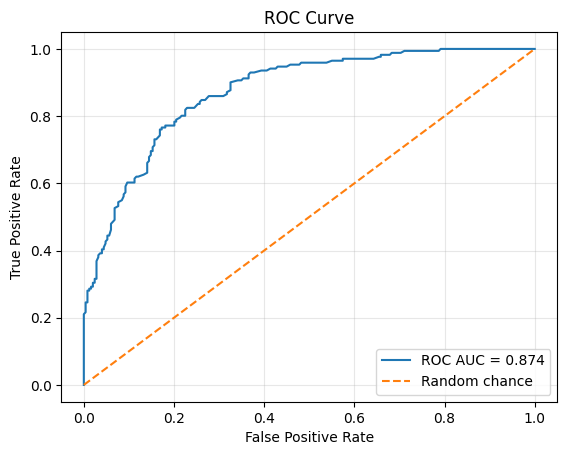

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

PRECISION-RECALL (AUPRC)

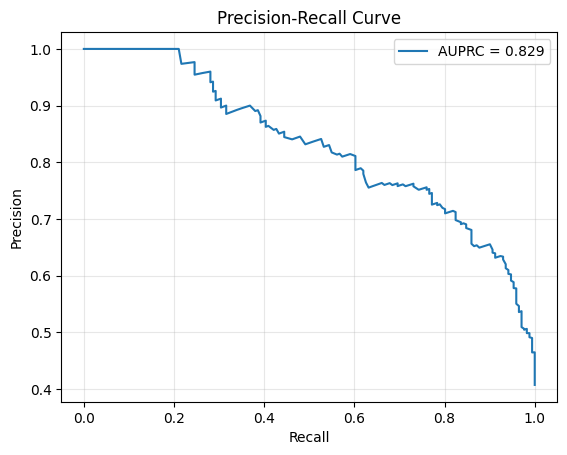

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
auprc = average_precision_score(y_test, y_prob)

plt.figure()
plt.plot(recall, precision, label=f"AUPRC = {auprc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Hyperparameter Tuning

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)


In [ ]:
df = pd.read_csv("Crop_training_data_FULL.csv")

df["suitability_class"] = df["suitability_class"].map({
    "Unsuitable": 0,
    "Suitable": 1
})

# Drop leakage column if exists
features_to_drop = ["suitability_class"]
if "suitability" in df.columns:
    features_to_drop.append("suitability")

X = df.drop(columns=features_to_drop)
y = df["suitability_class"]

# Convert crop name to numeric if exists
X = pd.get_dummies(X, drop_first=True)

TRAIN / TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


MODEL

In [ ]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

HYPERPARAMETER SEARCH SPACE

In [ ]:
param_dist = {
    "n_estimators": [200, 300, 400, 500, 600],
    "max_depth": [None, 10, 15, 20, 25],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced"]
}

RANDOMIZED SEARCH

In [ ]:
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=25,
    scoring="average_precision",   # AUPRC
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_rf = search.best_estimator_

print("\n=== BEST RANDOM FOREST PARAMETERS ===")
print(search.best_params_)
print(f"Best CV AUPRC: {search.best_score_:.4f}")

Fitting 3 folds for each of 25 candidates, totalling 75 fits

=== BEST RANDOM FOREST PARAMETERS ===
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 25, 'class_weight': 'balanced'}
Best CV AUPRC: 0.8074


TEST EVALUATION

In [ ]:
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
auprc = average_precision_score(y_test, y_proba)

print("\n=== TEST RESULTS (TUNED RF) ===")
print(f"Accuracy : {acc:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")
print(f"AUPRC    : {auprc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


=== TEST RESULTS (TUNED RF) ===
Accuracy : 0.7619
ROC AUC  : 0.8435
AUPRC    : 0.8062

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.88      0.81       249
           1       0.78      0.58      0.67       171

    accuracy                           0.76       420
   macro avg       0.77      0.73      0.74       420
weighted avg       0.76      0.76      0.75       420



ROC CURVE

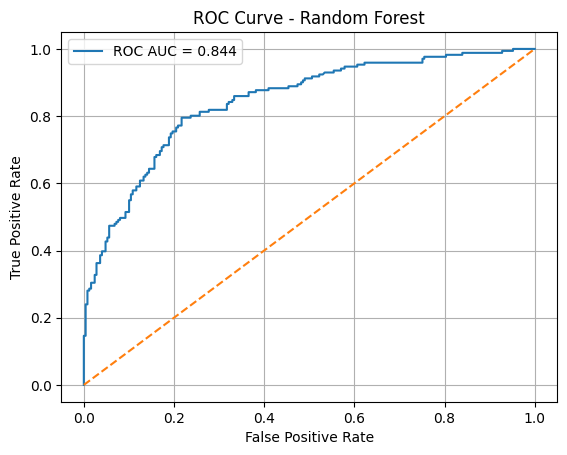

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

PRECISION-RECALL CURVE

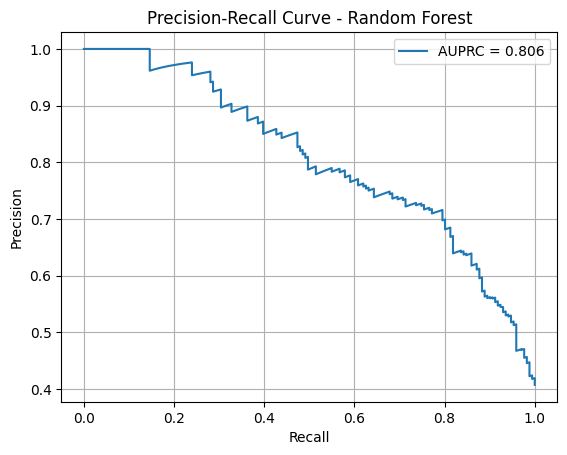

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.figure()
plt.plot(recall, precision, label=f"AUPRC = {auprc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

FEATURE IMPORTANCE


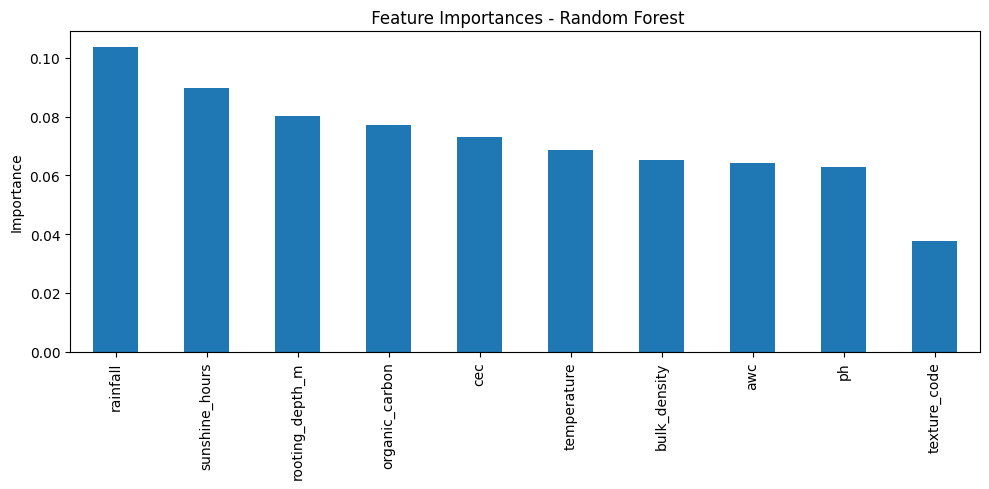

In [ ]:
importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.head(10).plot(kind="bar")
plt.title(" Feature Importances - Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()